In [1]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
import utils_2Q_gate_zp as ut
import qutip as qt
import scqubits as scq
from scipy.ndimage import gaussian_filter
from IPython.display import display, Math

#### Drag in 4-level system

In [2]:
drive_phi, drive_theta = False, True
truc1 = 300

In [3]:
EL   = 0.04 # GHz
EJ   = 10 # Soft Zero Pi (Gyenis)
E_CJ = 20
E_C  = 0.04
phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 100)
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=30, truncated_dim=truc1)
n_theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truc1)
n_phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truc1)
n_Phi = 2*np.pi * qt.Qobj(n_phi)
n_Theta = 2*np.pi * qt.Qobj(n_theta)

In [4]:
evals = zero_pi.eigenvals(evals_count=truc1)
H0 = 2*np.pi *qt.Qobj(np.diag(evals))

In [11]:
## find hilbert space
thresh = 1e-8
hspace_charge = [0, 1]
for s in hspace_charge:
    for i in range(truc1):
        if np.abs(n_theta[s, i]/(2*np.pi)) > thresh and i not in hspace_charge:
            hspace_charge.append(i)
hspace_charge.sort()

print('threshold=', thresh)
print('num of truncation =', len(hspace_charge))
print('hilbert_space :')
dim = 10
data = hspace_charge
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

threshold= 1e-08
num of truncation = 161
hilbert_space :
0, 1, 2, 3, 6, 7, 9, 10, 11, 13 ,
15, 16, 17, 19, 21, 22, 25, 26, 28, 29 ,
32, 33, 36, 37, 40, 42, 43, 48, 49, 50 ,
51, 52, 56, 57, 59, 60, 61, 62, 63, 68 ,
69, 71, 72, 74, 75, 77, 81, 84, 85, 87 ,
88, 89, 90, 96, 97, 98, 99, 101, 104, 105 ,
106, 110, 111, 112, 113, 117, 118, 119, 120, 124 ,
125, 128, 129, 132, 133, 136, 137, 139, 140, 144 ,
145, 147, 148, 151, 152, 156, 157, 159, 160, 161 ,
163, 166, 167, 169, 170, 174, 175, 176, 179, 180 ,
181, 182, 187, 188, 189, 192, 193, 198, 199, 200 ,
201, 202, 207, 208, 212, 213, 215, 216, 220, 221 ,
226, 227, 228, 229, 232, 233, 236, 237, 238, 239 ,
244, 245, 246, 247, 248, 249, 250, 251, 256, 257 ,
258, 261, 262, 263, 264, 269, 270, 271, 272, 273 ,
274, 277, 278, 281, 282, 290, 291, 294, 295, 298 ,
299 ,


In [5]:
w_0_2 = (evals[2] - evals[0])
w_2_6 = (evals[6] - evals[2])
w_3_6 = (evals[6] - evals[3])
w_1_3 = (evals[3] - evals[1])
display(Math(r"\omega_{a}^{0-2} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_0_2, w_0_2*2*np.pi)  ))
display(Math(r"\omega_{a}^{2-6} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_2_6, w_2_6*2*np.pi)  ))
display(Math(r"\omega_{a}^{3-6} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_3_6, w_3_6*2*np.pi)  ))
display(Math(r"\omega_{a}^{1-3} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_1_3, w_1_3*2*np.pi)  ))
display(Math(r"n_{a}^{0-2} = %.3f, \ n_{a}^{2-6} = %.3f, \ n_{a}^{3-6} = %.3f, \ n_{a}^{1-3} = %.3f"
             %(n_theta[0,2], n_theta[2,6], n_theta[3,6], n_theta[1,3])  ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [21]:
w_0_10 = (evals[10] - evals[0])
w_1_10 = (evals[10] - evals[1])
w_0_11 = (evals[11] - evals[0])
w_1_11 = (evals[11] - evals[1])
display(Math(r"\omega_{a}^{0-10} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_0_10, w_0_10*2*np.pi)  ))
display(Math(r"\omega_{a}^{1-10} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_1_10, w_1_10*2*np.pi)  ))
display(Math(r"\omega_{a}^{0-11} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_0_11, w_0_11*2*np.pi)  ))
display(Math(r"\omega_{a}^{1-11} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_1_11, w_1_11*2*np.pi)  ))
display(Math(r"n_{a}^{0-10} = %.3f, \ n_{a}^{1-10} = %.3f, \ n_{a}^{0-11} = %.3f, \ n_{a}^{1-11} = %.3f"
             %(n_theta[0,10], n_theta[1,10], n_theta[0,11], n_theta[1,11])  ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
thresh = 1e-3
w_trans = []
trans = []
trans_mat = []
for i in range(truc1):
    for j in np.arange(i+1, truc1):
        if abs(n_theta[i, j]) > thresh:
            f = np.round( abs(evals[i] - evals[j]), 8 )
            transition = str(i) + '-' + str(j)

            w_trans.append(f)
            trans.append(transition)
            trans_mat.append( np.round( np.abs(n_theta[i, j]) , 3))

# for i, _ in enumerate(trans):
#     print(i, trans[i], w_trans[i], trans_mat[i])

Text(0.5, 1.0, '$n_\\theta$ (Abdelhafez2020)')

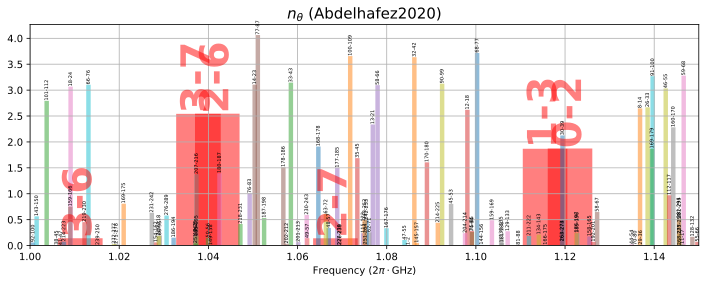

In [7]:
fig, ax = plt.subplots(figsize=(12,4))
y_shift = 0.005
state_overlap = ['0-10']
x_shift = [-0.3]
x_min, x_max = 1, 1.15
for i,_ in enumerate(w_trans):
    if x_min < w_trans[i] < x_max:# and trans_mat[i] < 2:
        if trans[i] in ['0-2', '2-6', '3-6', '1-3', '2-7', '3-7',]:
            plt.bar(w_trans[i], trans_mat[i], width=0.01, color='red', alpha=0.5)
            plt.text(w_trans[i], trans_mat[i] +y_shift, trans[i],
                     ha="center", va="bottom", rotation=90, fontsize=40, fontweight='bold', color='red', alpha=0.5)
        else:
            plt.bar(w_trans[i], trans_mat[i], width=0.001, alpha=0.5)
            plt.text(w_trans[i], trans_mat[i] +y_shift, trans[i], ha="center", va="bottom", rotation=90, fontsize=5)

# plt.ylim(0,0.17)
plt.xlim(x_min,x_max)
plt.xlabel(r'Frequency (2$\pi\cdot$GHz)')
plt.grid()
# plt.xticks(np.arange(x_min, x_max, 2))  # Set custom x-axis ticks
# plt.ylabel('Max population during X gate')
ax.set_title(r'$n_\theta$ (Abdelhafez2020)', fontsize=15)
# plt.title(r'$n_\phi:\psi_0=$'+f'{state_good}', fontsize=15)

#### Matrix element table

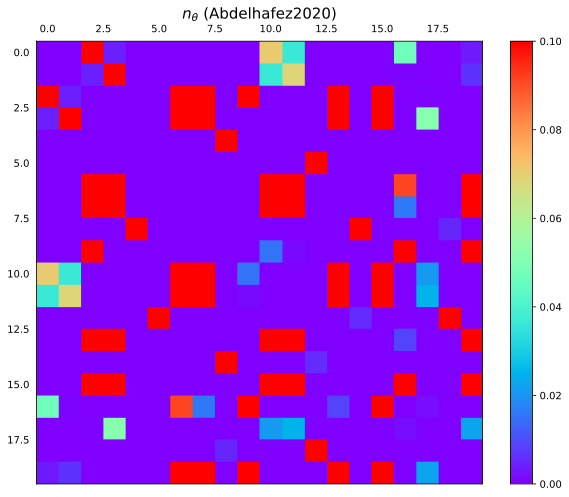

In [20]:
vmax = 0.1
truc_mat = 20
fig, ax = plt.subplots(figsize=(10,8))
font_size = 15
plt.imshow(np.abs(n_theta[:truc_mat,:truc_mat]), vmax=vmax, aspect="auto",cmap='rainbow')
ax.set_title(r'$n_\theta$ (Abdelhafez2020)', fontsize=15)
# plt.title(r'$n_{\theta}$($v_{max}$='+f'{vmax})' , pad=8,fontsize=font_size)
# ax.set_xticks(np.arange(0, truc_mat, 1), np.arange(0, truc_mat, 1), fontsize=6)
# ax.set_yticks(np.arange(0, truc_mat, 1), np.arange(0, truc_mat, 1))
ax.xaxis.tick_top()
# ax.set_xticks(np.arange(-.5, truc_mat, 1), minor=True)
# ax.set_yticks(np.arange(-.5, truc_mat, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar()
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')